# **Jordan Health Services — Building Queryable Skills from a GitHub Repo**

Point `%%skill-build` at a GitHub repository and ARGUS turns the **data**
inside it into queryable skills — you write no loading code. It clones the
repo, sorts every file by type, ignores the modelling scripts and notebooks,
proposes a skill plan, and pauses for your approval before building.

This repo is a good stress test because it mixes formats that normally need
very different handling: a **GeoTIFF population raster**, **administrative-
boundary polygons** (country → governorate → district → subdistrict),
**facility point tables**, and large **synthetic patient-visit tables** — a
synthetic dataset for studying how health-service areas in Jordan could be
organised. ARGUS routes each format to the right builder and groups the files
into a handful of coherent skills.

The raster is the interesting part: its pixels hold population counts, but
that meaning lives only in the documentation, not the file. ARGUS reads the
docs to learn it, then exposes it as a plain question — *"what's the population
inside this polygon?"* — backed by zonal statistics over the raster. No GIS
code required.

Once built, the skills answer plain-language questions that compose across
population, geography, facilities, and patient records. The queries below start
with a single skill and build toward multi-skill questions.

Source: [github.com/izaslavsky/jordan-hsa-optimization](https://github.com/izaslavsky/jordan-hsa-optimization) · MIT (repo) / CC-BY-4.0
(WorldPop rasters)

####   **Choose your language model**

Argus is model-agnostic — you can plug in any major LLM provider that offers a strong code-generation model. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

**This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users). If you don't have NRP access, swap in another provider — they all work the same way.

**Before you run the cell: save your API key as a Colab Secret**

Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the notebook with.

1. Click the 🔑 key icon in the left sidebar (**Secrets**).
2. Click **+ Add new secret**.
3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
   - `NRP_API_KEY` for NRP-served models
   - `OPENAI_API_KEY` for OpenAI
   - `ANTHROPIC_API_KEY` for Anthropic
   - `GOOGLE_API_KEY` for Google
   - `ZAI_API_KEY` for Z.ai
4. Paste your key into the **Value** field.
5. Toggle **Notebook access** on for this notebook.

If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

### Choosing a model

Argus generates and runs Python against real data on every turn. The model must be **excellent at coding** — not just capable of tool-calling. Chat-tuned models with strong conversational performance but weaker code generation produce Argus runs that fail on real datasets, retry many times, or drift into wordy exploration without converging.

**What to pick**: choose your provider's top-tier code-focused model — the one they market for agentic coding, software engineering, or long-context multi-step work. Avoid the chat-tuned default.

**Known quirks**: heavily-quantized model variants (4-bit weights or smaller) can complete workflows but with excess retries and lower-quality code. If you have the choice between quantized and full-precision for the same model, pick full-precision.

In [1]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### **Install Argus from GitHub Repo**

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 15 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, array-skill-builder, ckan-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states, zenodo-skill-builder

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [ ]:
%reset

In [3]:
%%skill-build
https://github.com/izaslavsky/jordan-hsa-optimization

I'll use the `repo-skill-builder` meta-skill since this is a GitHub repository URL. Let me read its instructions first.

I'll run `fetch.py` to clone the repo and classify its files.

The ROUTE is `combined` — 2 GeoTIFF rasters plus 17 tabular files (CSVs and GPKPs). Per the skill, I'll read both downstream builders and run both inventories, then propose at one gate. Let me read the metadata and both downstream SKILL.md files.

This is a combined build (2 GeoTIFF rasters + 17 tabular files). Let me set up tracking and run both inventories in parallel.

Running both inventories in parallel (tabular inventory on the clone, array inventory with `--dir` on the same clone).

Both inventories are complete. Now I'll read the README for dataset semantics before proposing. Let me update todos and read the key docs.

Let me read the rest of the README and the DATA_FLOW_ANALYSIS.md for the synthetic-data naming conventions and raster semantics.

I have everything needed for the proposal. Let me update todos and present the plan at the STOP gate.

I have everything needed. Here's the inventory summary and my proposed plan.

---

I've inspected `https://github.com/izaslavsky/jordan-hsa-optimization`. Here's what I found and what I propose:

**Source** : `jordan-hsa-optimization` — izaslavsky, MIT License. Hospital Service Area (HSA) optimization & climate-health analysis for Jordan. Code + data accompanying a research paper on delineating HSAs from patient trajectories.

**Files scanned** : 19 data files (12 CSV, 5 GPKG, 2 GeoTIFF) + 5 docs. Classification routed `combined` (array + tabular).

**Fingerprint grouping** : 8 tabular schema groups + 1 raster group (2 WorldPop GeoTIFFs).

**Proposed skills** (3):

**1. `jordan-hsa-patient-visits`** *(tabular → Parquet)*
- **Entity** : each row is a synthetic patient visit (a diagnosis event)
- **Merged from** : 4 `*_patient_visits.csv` — `SYNINF`, `SYNNCD`, `SYNMODINF`, `SYNMODNCD` (~50K–476K rows each, **~1.3M total** )
- **Discriminator** : `network` (INF / NCD / MODINF / MODNCD) + `disease_class` (infectious vs non-communicable)
- **Key columns** : `patientid`, `gender`, `ageatdiagnosis`, `governorate`, `diagnosis`, `general_category`, `datetimediagnosisentered`, `healthfacility`, `healthfacilitytype`
- Also folds in the 4 `*_groups_of_diagnoses.csv` as a reconciled diagnosis-code → category lookup (see open question 1)
- **Note** : All patient data is synthetic (privacy-preserving); `SYN` prefix.

**2. `jordan-hsa-facilities`** *(spatial → GPKG, points from lat/lon)*
- **Entity** : each row is a healthcare facility with location
- **Merged from** : 4 `*_facility_coordinates.csv` (**~760 facilities** )
- **Discriminator** : `network` + `disease_class`
- **Key columns** : `healthfacility`, `healthfacilitytype`, `governorate`, `Latitude`, `Longitude` → `lat`/`lon` geometry
- **Join** : `healthfacility` name → patient visits; points spatially → admin boundaries & population raster

**3. `jordan-hsa-geography`** *(combined spatial + raster)*
- **Entity** : Jordan administrative-unit polygons + WorldPop 2020 population grid
- **Merged from** : 5 GPKPs — national boundary, governorates (×2 sets), districts (51), subdistricts (89) — **~165 polygons** ; plus 2 WorldPop rasters
- **Raster helpers** (per array-skill-builder Step 6c): `population_in_polygon()` / `zonal_sum()`, `zonal_stats()`, `sample_at()` over both raster variants
- **Spatial join** : facility points fall inside governorate/district polygons; `zonal_sum(governorate_geom)` = population of that governorate. All EPSG:4326.

**Open questions (please confirm):**

1. **Diagnosis-groups near-match.** The 4 diagnosis-grouping CSVs split into two schemas: infectious files have `[Diagnosis, count, first_year, last_year, General_Diagnosis]` (5 cols); NCD files have `[…, General_Category, Unnamed:5, Unnamed:6, Unnamed:7]` (8 cols). I'd reconcile `General_Diagnosis` ↔ `General_Category` → `general_category`, drop the 3 `Unnamed` columns, and merge into one lookup table tagged by `disease_class`. OK?

2. **Canonical governorate layer.** There are **two** governorate polygon sets: `Jordan_governorates_simplified20m.gpkg` (8 cols, richer attrs incl. Arabic names + Wikidata) and `jordan_governorates.gpkg` (6 cols, shapeISO/shapeGroup). They draw borders slightly differently, so summing the population raster over each gives **contradictory per-governorate totals** . I propose designating `Jordan_governorates_simplified20m.gpkg` canonical for all aggregation/joins and demoting the other to reference-only. OK, or do you prefer the `jordan_governorates.gpkg` set?

3. **Raster pixel semantics.** README calls both rasters "population density" but reports absolute national totals (UNadj ~10.2M, constrained ~7M) and uses them for "coverage calculations" / "assigns population exclusively to building footprint cells." This indicates **persons-per-pixel counts** (WorldPop `ppp` = people-per-pixel), so `zonal_sum(polygon)` = that polygon's population — not a density average. Confirm? (This determines whether `zonal_sum` is even the right helper.)

Reply with **"yes"** to proceed as proposed, or with edits (e.g. "merge facilities into geography", "rename skill-2", "split patient-visits by disease class into 2 skills").

(Resume state on disk: `/tmp/repo-skills/jordan-hsa-optimization/` — source files, `_inventory.json`, and `_repo_metadata.json` are all there; array inventory at `/tmp/array-skill-inv/jordan-hsa/_inventory.json`.)

In [4]:
%%ask
Yes, please create these skills.

I'll build the three approved skills now. Let me set up my task tracking and verify the staged state first.

The working directory is empty — the proposal phase staged files in `/tmp` which I can't access. I'll need to clone fresh into my working directory. Let me read the build-phase instructions from the skill builders and start the clone in parallel.

I'm in a fresh working directory (the previous proposal staged files in `/tmp`). I need to re-run `fetch.py` to re-clone and re-classify, then build. Let me run fetch and read the downstream builder instructions in parallel.

Good. The fetch cloned everything to `/tmp/repo-skills/jordan-hsa-optimization/`. Now let me read the rest of the tabular SKILL.md (the critical build/SKILL.md writing steps) and the array-skill-builder in parallel.

I've read both builder SKILLs thoroughly. Now let me run the two inventories (tabular + array) on the fresh clone to get the exact schemas and file paths my build scripts need.

...

Now the facilities skill SKILL.md.

Now the geography skill (the combined spatial + raster one) — the most complex, with the canonical-layer and pixel-semantics decisions baked in.

Now the critical verification step — load each skill's data and run representative queries from the SKILL.md examples to confirm they actually work.

All checks passed. Now cleanup: delete the source clone + inventory scratch per the mandatory cleanup steps, and remove my build/verify scripts so only the skills remain.

All three skills built and verified. Build scratch and source clone cleaned up. Here's the summary.

---

✓ Built skill **jordan-hsa-patient-visits** at `_skills_/jordan-hsa-patient-visits/SKILL.md`.

Each row is a synthetic patient visit (a diagnosis event) at a Jordanian healthcare facility (942,452 visits, spanning 2019–2024 across four patient-flow networks).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Patient-flow network | `network` | INF, MODINF, NCD, MODNCD |
| Disease class | `disease_class` | infectious, non-communicable |
| Governorate | `governorate` | Amman, Irbid, Zarqa, Balqa, Karak |
| Facility type | `healthfacilitytype` | Comprehensive Center, Hospital, Primary Center, Educational Hospital |
| Disease category | `general_category` | Hypertension, Diabetes Mellitus, Diarrheal Diseases, Scabies |
| Demographics | `gender`, `ageatdiagnosis` | FEMALE/MALE; age in years |
| Time | `datetimediagnosisentered` | 2019-01-01 → 2024-01-31 |

**Example queries:**
- **By network** — "How do MODNCD and NCD visit counts compare by governorate?"
- **By category** — "Top 10 disease categories in the baseline NCD network"
- **By demographics** — "Mean age at diabetes diagnosis, by gender and network"
- **By facility** — "Which facilities see the most scabies cases?"
- **Over time** — "Monthly hypertension visits in 2022 across all networks"
- **Using the lookup** — "Which general categories contain both INF and NCD diagnoses?"
- **Cross-skill** — "Get coordinates of the top 20 facilities by visit volume" (joins to `jordan-hsa-facilities`)

A companion **diagnosis-lookup** table (1,882 rows) reconciles the 4 per-network `groups_of_diagnoses.csv` files into one diagnosis-code → general-category reference. Caveat: `general_category` has case inconsistencies (`Hypertension` vs `hypertension`); match case-insensitively.

The skill returns a `DataFrame` you can join with `jordan-hsa-facilities` (on `healthfacility`) and `jordan-hsa-geography` (on `governorate`) in the same `%%ask` cell.

---

✓ Built skill **jordan-hsa-facilities** at `_skills_/jordan-hsa-facilities/SKILL.md`.

Each row is a healthcare facility in Jordan with point location, type, governorate, and network tag (766 facility-network rows, 201 distinct facility names, EPSG:4326).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Facility type | `healthfacilitytype` | Primary Center, Comprehensive Center, Hospital, Specialized Medical Center, Field Hospital |
| Governorate | `governorate` | Amman, Karak, Irbid, Mafraq, Zarqa |
| Network | `network` | INF, MODINF, NCD, MODNCD |
| Disease class | `disease_class` | infectious, non-communicable |
| Facility name | `healthfacility` | Abu Alanda CC, Ader Primary Center, Al Hussain New Salt Hospital |
| Spatial area | (`lat`, `lon` geometry) | any rectangle in WGS84 |

**Example queries:**
- **By type** — "Show all hospitals in Jordan"
- **By governorate** — "Facilities of each type per governorate"
- **Compare networks** — "Which facilities appear in both INF and NCD networks?"
- **Spatial** — "Facilities within 50 km of Amman city center"
- **Cross-skill** — "Map facilities that see >5,000 hypertension visits" (joins to `jordan-hsa-patient-visits`)
- **Cross-skill** — "Assign each facility to its district polygon" (joins to `jordan-hsa-geography`)

Caveat: networks share facility sets — `INF`/`MODINF` carry the same 188 facilities, `NCD`/`MODNCD` the same 195. Deduplicate on `healthfacility` when you need physical buildings.

The skill returns a `GeoDataFrame` (EPSG:4326 points) you can spatially join with `jordan-hsa-geography` boundaries or attribute-join with `jordan-hsa-patient-visits`.

---

✓ Built skill **jordan-hsa-geography** at `_skills_/jordan-hsa-geography/SKILL.md`.

Each query targets Jordan administrative boundaries (12 governorates, 51 districts, 89 subdistricts, national outline) and/or WorldPop 2020 population rasters (UNadj and constrained, ~100 m persons-per-pixel).

**What you can filter on:**

| Dimension | Field/layer | Example values |
|---|---|---|
| Admin level | layer | governorates (12), districts (51), subdistricts (89), national_boundary |
| Governorate name | `name_en` | Amman, Irbid, Zarqa, Balqa, Karak, Ma'an |
| District → governorate | `name_en_2` | Balqa, Amman, Irbid |
| Raster variant | `variant` arg | UNadj (primary, sums to 10.2M), constrained (built-up, sums to 7.1M) |
| Spatial area | geometry | any polygon for `population_in_polygon` / `zonal_stats` |
| Point location | `sample_at(lon, lat)` | any WGS84 coordinate |

**Example queries:**
- **List boundaries** — "What are the 12 governorates and their Arabic names?"
- **Population of one unit** — "Estimated 2020 population of Amman governorate" → `population_in_polygon(geom)`
- **Population ranking** — "Population ranking of all governorates" → `zonal_stats(gov)`
- **Compare variants** — "How do UNadj and constrained totals differ per governorate?"
- **Drill down** — "Districts in Balqa governorate with their populations"
- **Point sample** — "Population pixel value at Aqaba" → `sample_at(35.0, 29.53)`
- **Cross-skill** — "Assign each facility to its governorate" (spatial join with `jordan-hsa-facilities`)
- **Cross-skill** — "Per-governorate visit counts joined to population" (with `jordan-hsa-patient-visits`)

Two resolved judgement calls baked into the skill (both confirmed at the proposal gate): **(1)** `Jordan_governorates_simplified20m` is the canonical governorate layer for all aggregation — the alternate `jordan_governorates.gpkg` is kept reference-only because its borders differ and give contradictory totals; **(2)** raster pixels are persons-per-pixel (UNadj national sum = 10.2M matches Jordan's UN 2020 estimate), so `zonal_sum` = population.

The skill returns `GeoDataFrame`s for boundaries and numeric results from the raster helpers; population sums join naturally to the other two skills via `governorate`/`name_en`.

---

All three skills are now in `_skills_/` and will be picked up automatically on the next `%%ask` cell. Verification confirmed: all data files load, example queries run, cross-skill joins resolve (187 facility names overlap between visits and facilities, Amman governorate population = 3.9M via zonal sum), and source scratch has been cleaned up.

####  1. Population

I'll use the `jordan-hsa-geography` skill I just built. Let me read its instructions first.

The skill provides a `zonal_stats` helper that does exactly this. I'll write a script that computes population per governorate and produces a choropleth map plus a bar chart.

Running the population computation and chart generation script.

Retrying without the timeout parameter.

Here are the results — population estimates per Jordanian governorate (WorldPop 2020, UN-adjusted, summed from the ~100 m population raster within each boundary polygon).

**Population by Governorate**

| Governorate | Population | Share |
|---|---:|---:|
| Amman | 3,912,744 | 38.5% |
| Irbid | 1,846,909 | 18.2% |
| Zarqa | 1,445,296 | 14.2% |
| Balqa | 671,993 | 6.6% |
| Mafraq | 573,829 | 5.6% |
| Karak | 392,524 | 3.9% |
| Jarash | 317,499 | 3.1% |
| Madaba | 244,399 | 2.4% |
| Ajloun | 244,060 | 2.4% |
| Aqaba | 209,977 | 2.1% |
| Ma'an | 176,237 | 1.7% |
| Tafilah | 140,010 | 1.4% |
| **Total** | **10,175,477** | 100% |

**Key takeaways:**
- **Amman alone holds ~39% of the population** (3.9M) — roughly **2× Irbid** (1.8M) and **2.7× Zarqa** (1.4M). The top-3 governorates (Amman + Irbid + Zarqa) account for **~71%** of the national total.
- At the other end, **Tafilah** (~140K), **Ma'an** (~176K), and **Aqaba** (~210K) together hold just **~5%** of the population despite covering large areas of the southern desert.
- The national sum (~10.18M) closely matches Jordan's UN 2020 estimate (~10.2M), confirming the UN-adjusted raster as the appropriate variant for general population totals.


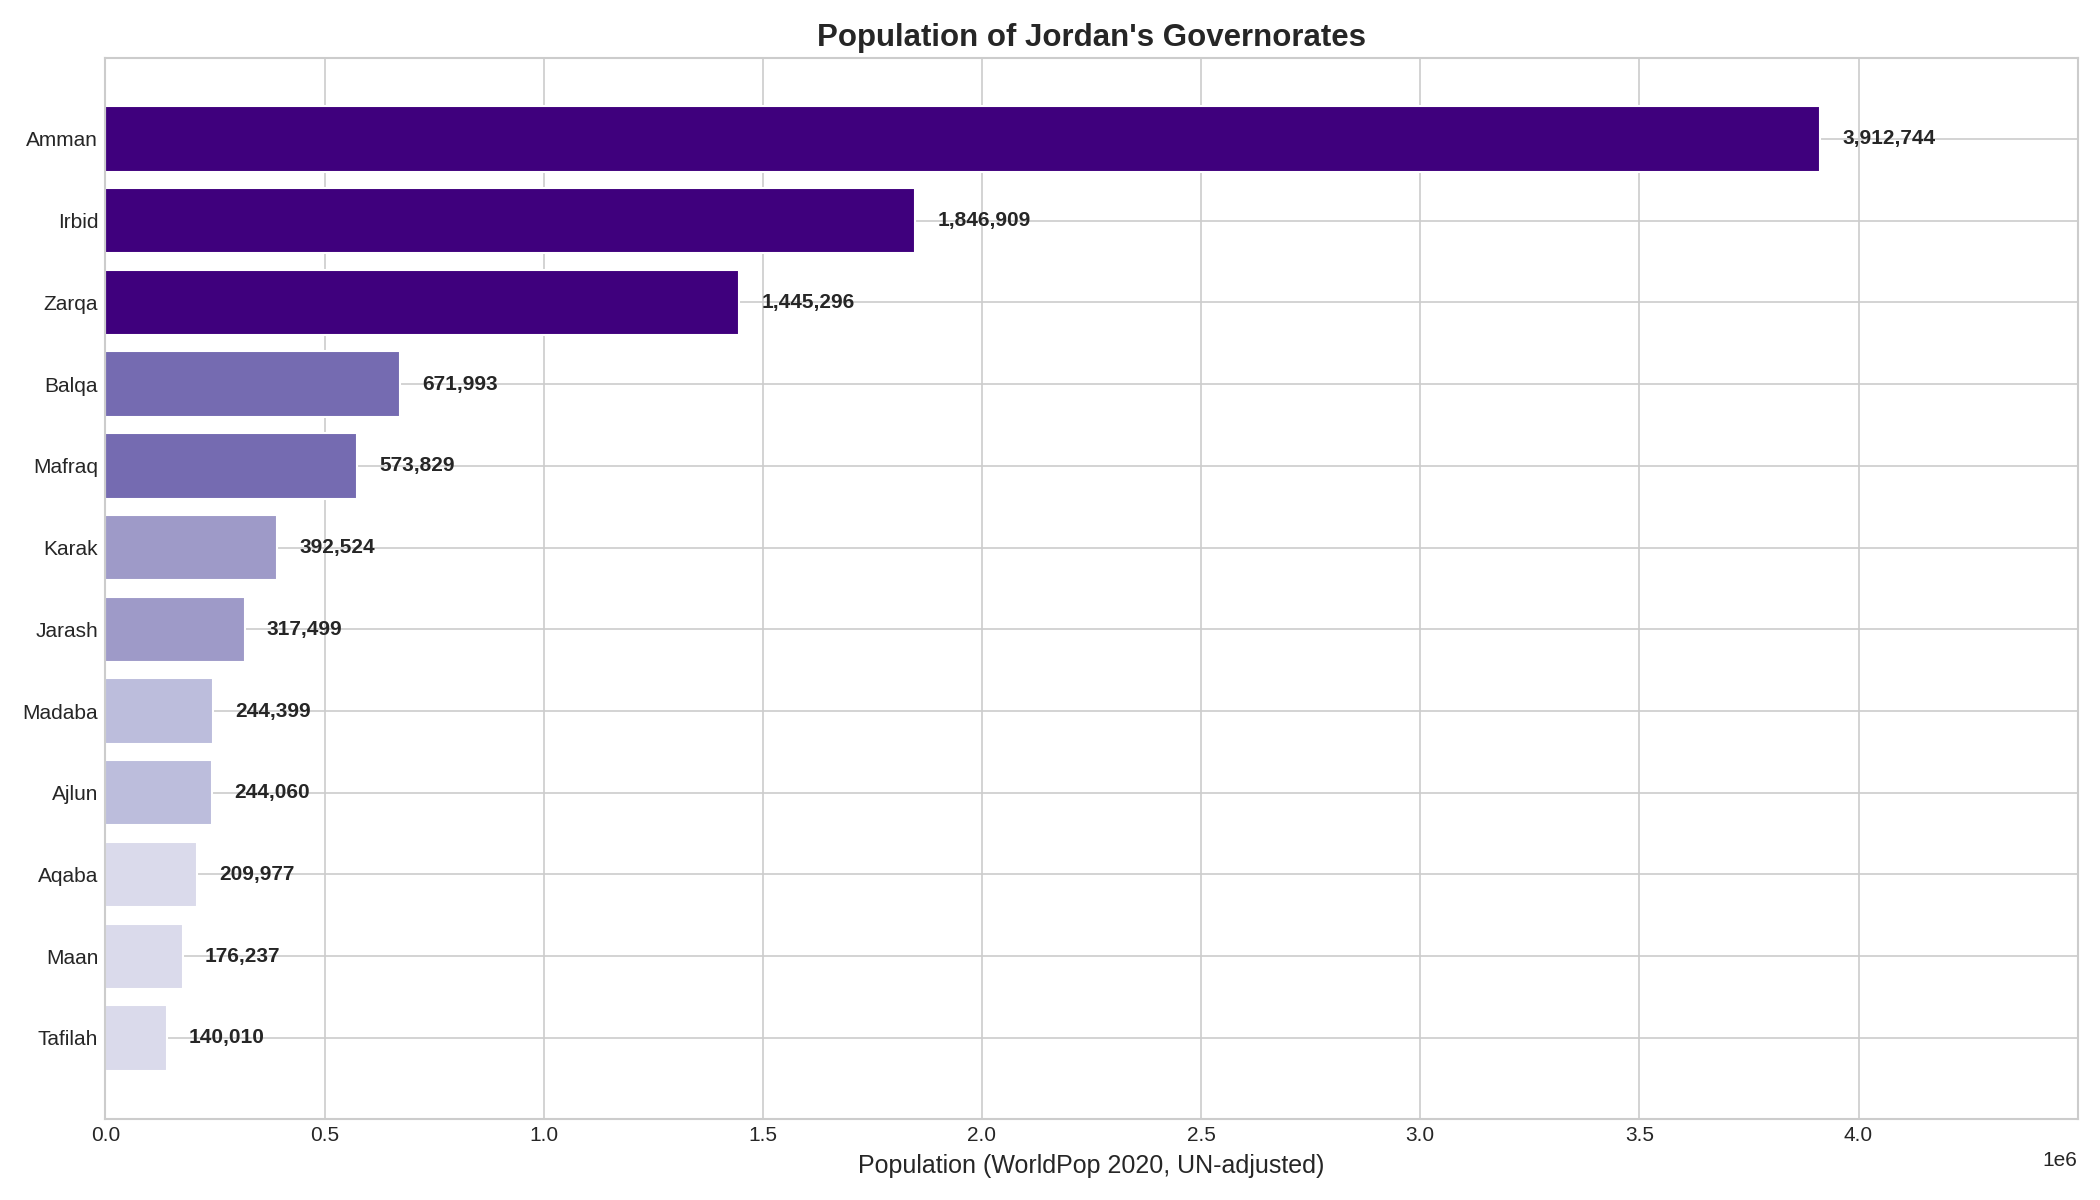

In [5]:
%%ask
How many people live in each of Jordan's governorates? Show them on a map
shaded by population.

#### 2. Care capacity

I'll read the facilities skill to understand its interface, then fetch and map the data.

Here are Jordan's healthcare facilities — **201 unique physical facilities** (deduplicated from 766 network rows) mapped and tallied by type and governorate.

**Facility Type × Governorate** (unique facilities)

| Governorate | Primary Center | Comprehensive Center | Hospital | Field Hospital | Specialized Medical Center | Educational Hospital | **Total** |
|---|---:|---:|---:|---:|---:|---:|---:|
| Amman | 29 | 26 | 3 | 1 | 0 | 0 | **59** |
| Karak | 33 | 7 | 1 | 0 | 0 | 0 | **41** |
| Irbid | 10 | 4 | 3 | 1 | 2 | 1 | **21** |
| Mafraq | 6 | 7 | 2 | 0 | 1 | 0 | **16** |
| Zarqa | 3 | 8 | 2 | 0 | 0 | 0 | **13** |
| Balqa | 7 | 2 | 3 | 0 | 0 | 0 | **12** |
| Madaba | 4 | 5 | 2 | 0 | 0 | 0 | **11** |
| Jarash | 7 | 2 | 1 | 0 | 0 | 0 | **10** |
| Ajloun | 2 | 3 | 1 | 0 | 0 | 0 | **6** |
| Aqaba | 2 | 2 | 0 | 1 | 0 | 0 | **5** |
| Ma'an | 0 | 2 | 2 | 0 | 0 | 0 | **4** |
| Tafila | 0 | 2 | 1 | 0 | 0 | 0 | **3** |
| **Total** | **103** | **70** | **21** | **3** | **3** | **1** | **201** |


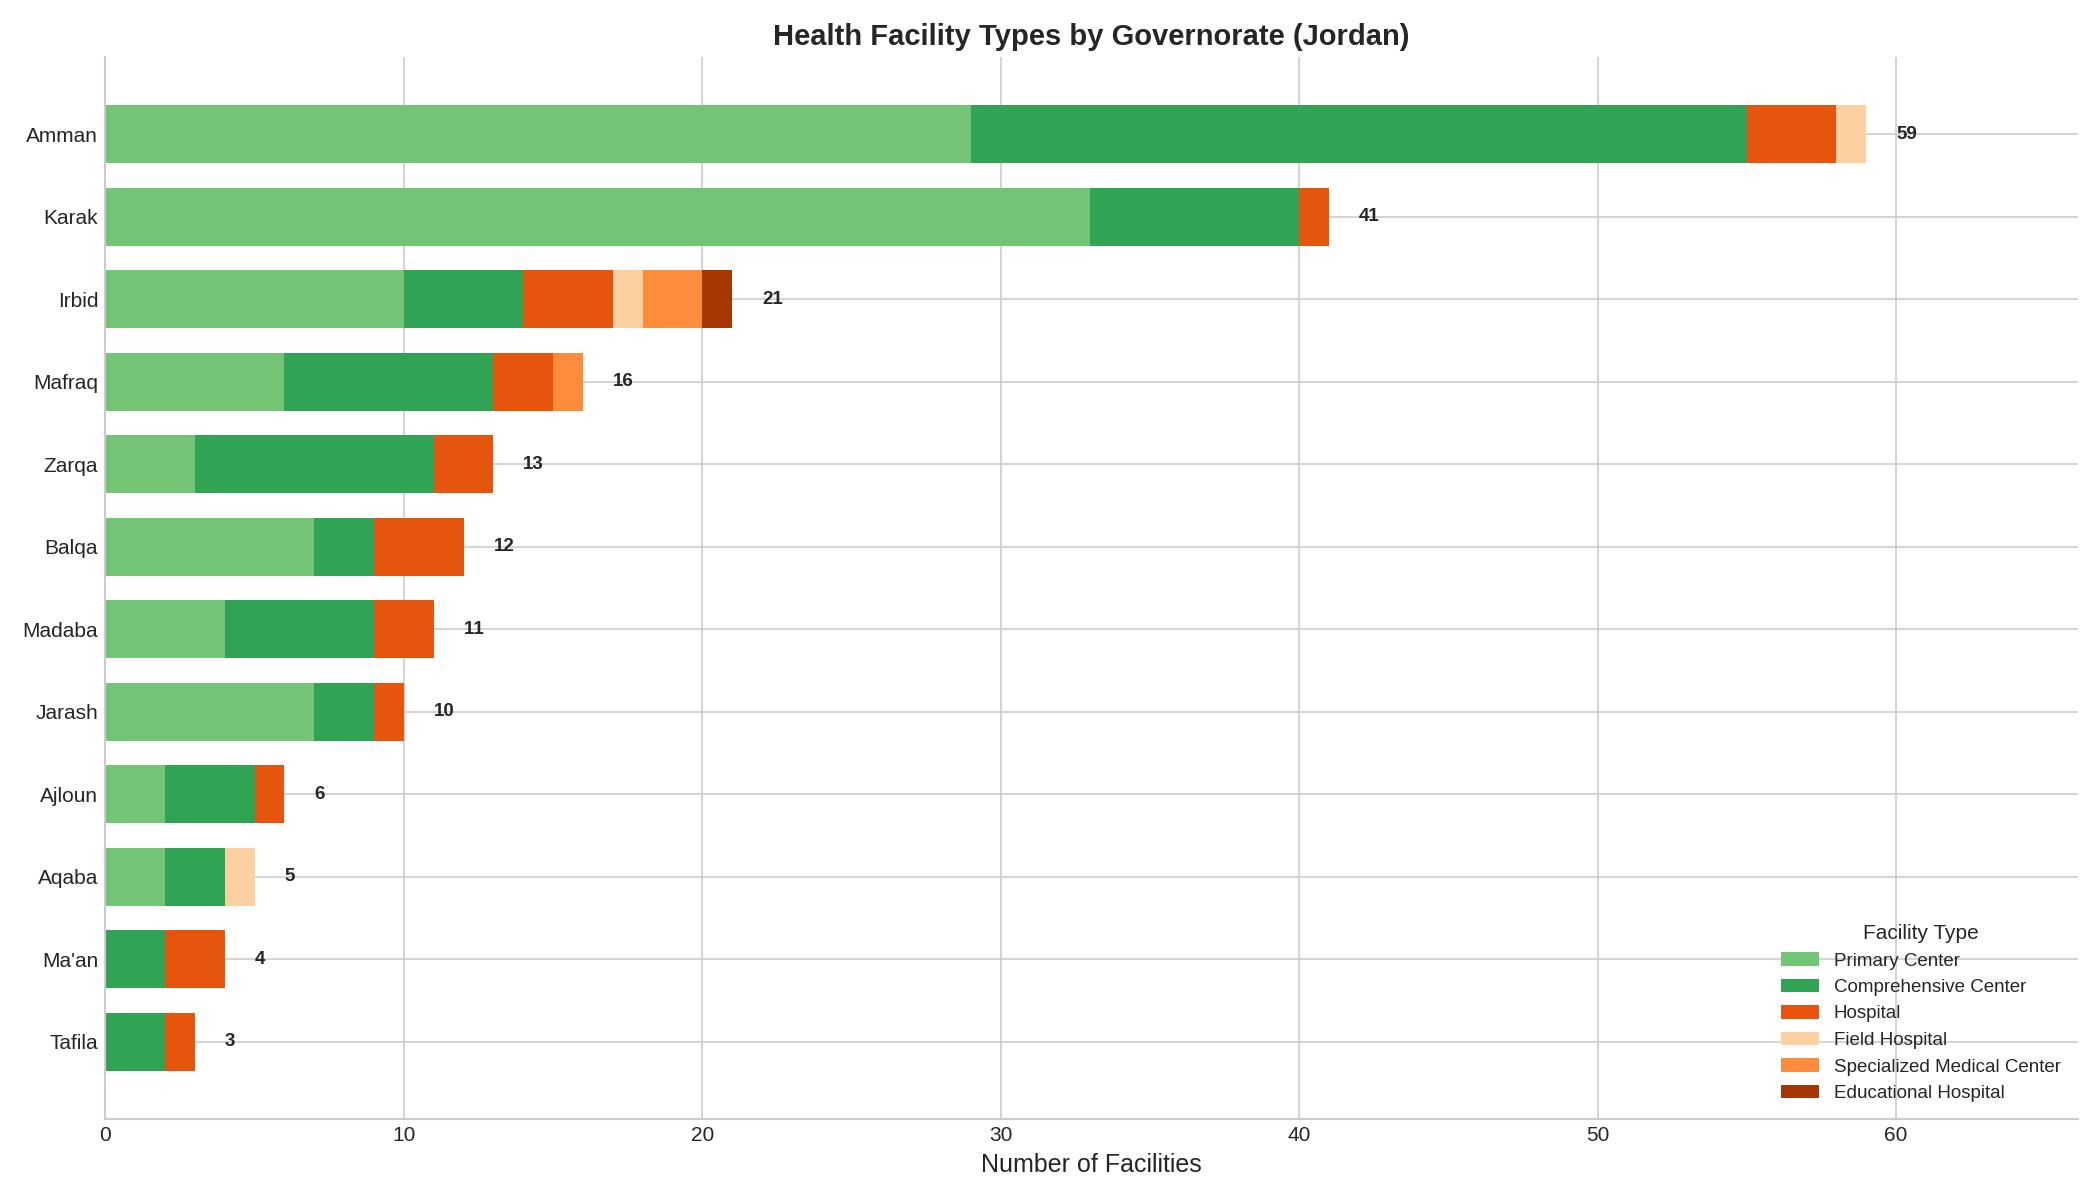

**Key takeaways:**

- **Amman has the most facilities (59)** — nearly double the next governorate, consistent with it holding ~39% of the population. Karak is a strong second (41) despite a much smaller population (~393K), giving it the highest facilities-per-capita ratio in the country.
- **Primary Centers and Comprehensive Centers dominate** the system (103 + 70 = 86% of all facilities). These are the front-line primary-care facilities.
- **Hospitals are concentrated.** Of the 21 hospitals, the most are in **Balqa (3), Irbid (3), and Amman (3)** — but several governorates with substantial populations (Zarqa: 1.4M people) have only **2 hospitals** , and **Ma'an has no Primary Centers at all** , relying on 2 Comprehensive Centers and 2 Hospitals.
- **Tertiary/specialized care is rare and clustered.** All 3 Specialized Medical Centers and the 1 Educational Hospital are in **Irbid and Mafraq** (the north), leaving the central and southern governorates without these facility types.

In [6]:
%%ask
Map Jordan's health facilities and tell me how many of each type are in each governorate.

#### 3. Where's the access gap

I'll combine the population data (from `jordan-hsa-geography`) with the facility counts (from `jordan-hsa-facilities`) to compute people-per-facility. Let me first consult both skills to use their APIs correctly.

Now I'll write a script that joins population to facility counts and ranks governorates by people-per-facility.

The merge left NaNs — likely a governorate name mismatch between the two datasets. Let me check.

Three governorate name spelling mismatches between datasets (`Ajlun`/`Ajloun`, `Maan`/`Ma'an`, `Tafilah`/`Tafila`). I'll harmonize them before the join.

The script ran successfully. Now let me record the name-mismatch lesson to the Learnings file, since this was an edit-and-retry cycle.

Here are the results — Jordan's governorates ranked from most to least stretched, measured by people per health facility (WorldPop 2020 UN-adjusted population ÷ unique physical facilities).

| Rank | Governorate | Population | Facilities | People per Facility |
|---:|---|---:|---:|---:|
| 1 | Zarqa | 1,445,296 | 13 | **111,177** |
| 2 | Irbid | 1,846,909 | 21 | **87,948** |
| 3 | Amman | 3,912,744 | 59 | **66,318** |
| 4 | Balqa | 671,993 | 12 | **55,999** |
| 5 | Tafilah | 140,010 | 3 | **46,670** |
| 6 | Ma'an | 176,237 | 4 | **44,059** |
| 7 | Aqaba | 209,977 | 5 | **41,995** |
| 8 | Ajlun | 244,060 | 6 | **40,677** |
| 9 | Mafraq | 573,829 | 16 | **35,864** |
| 10 | Jarash | 317,499 | 10 | **31,750** |
| 11 | Madaba | 244,399 | 11 | **22,218** |
| 12 | Karak | 392,524 | 41 | **9,574** |


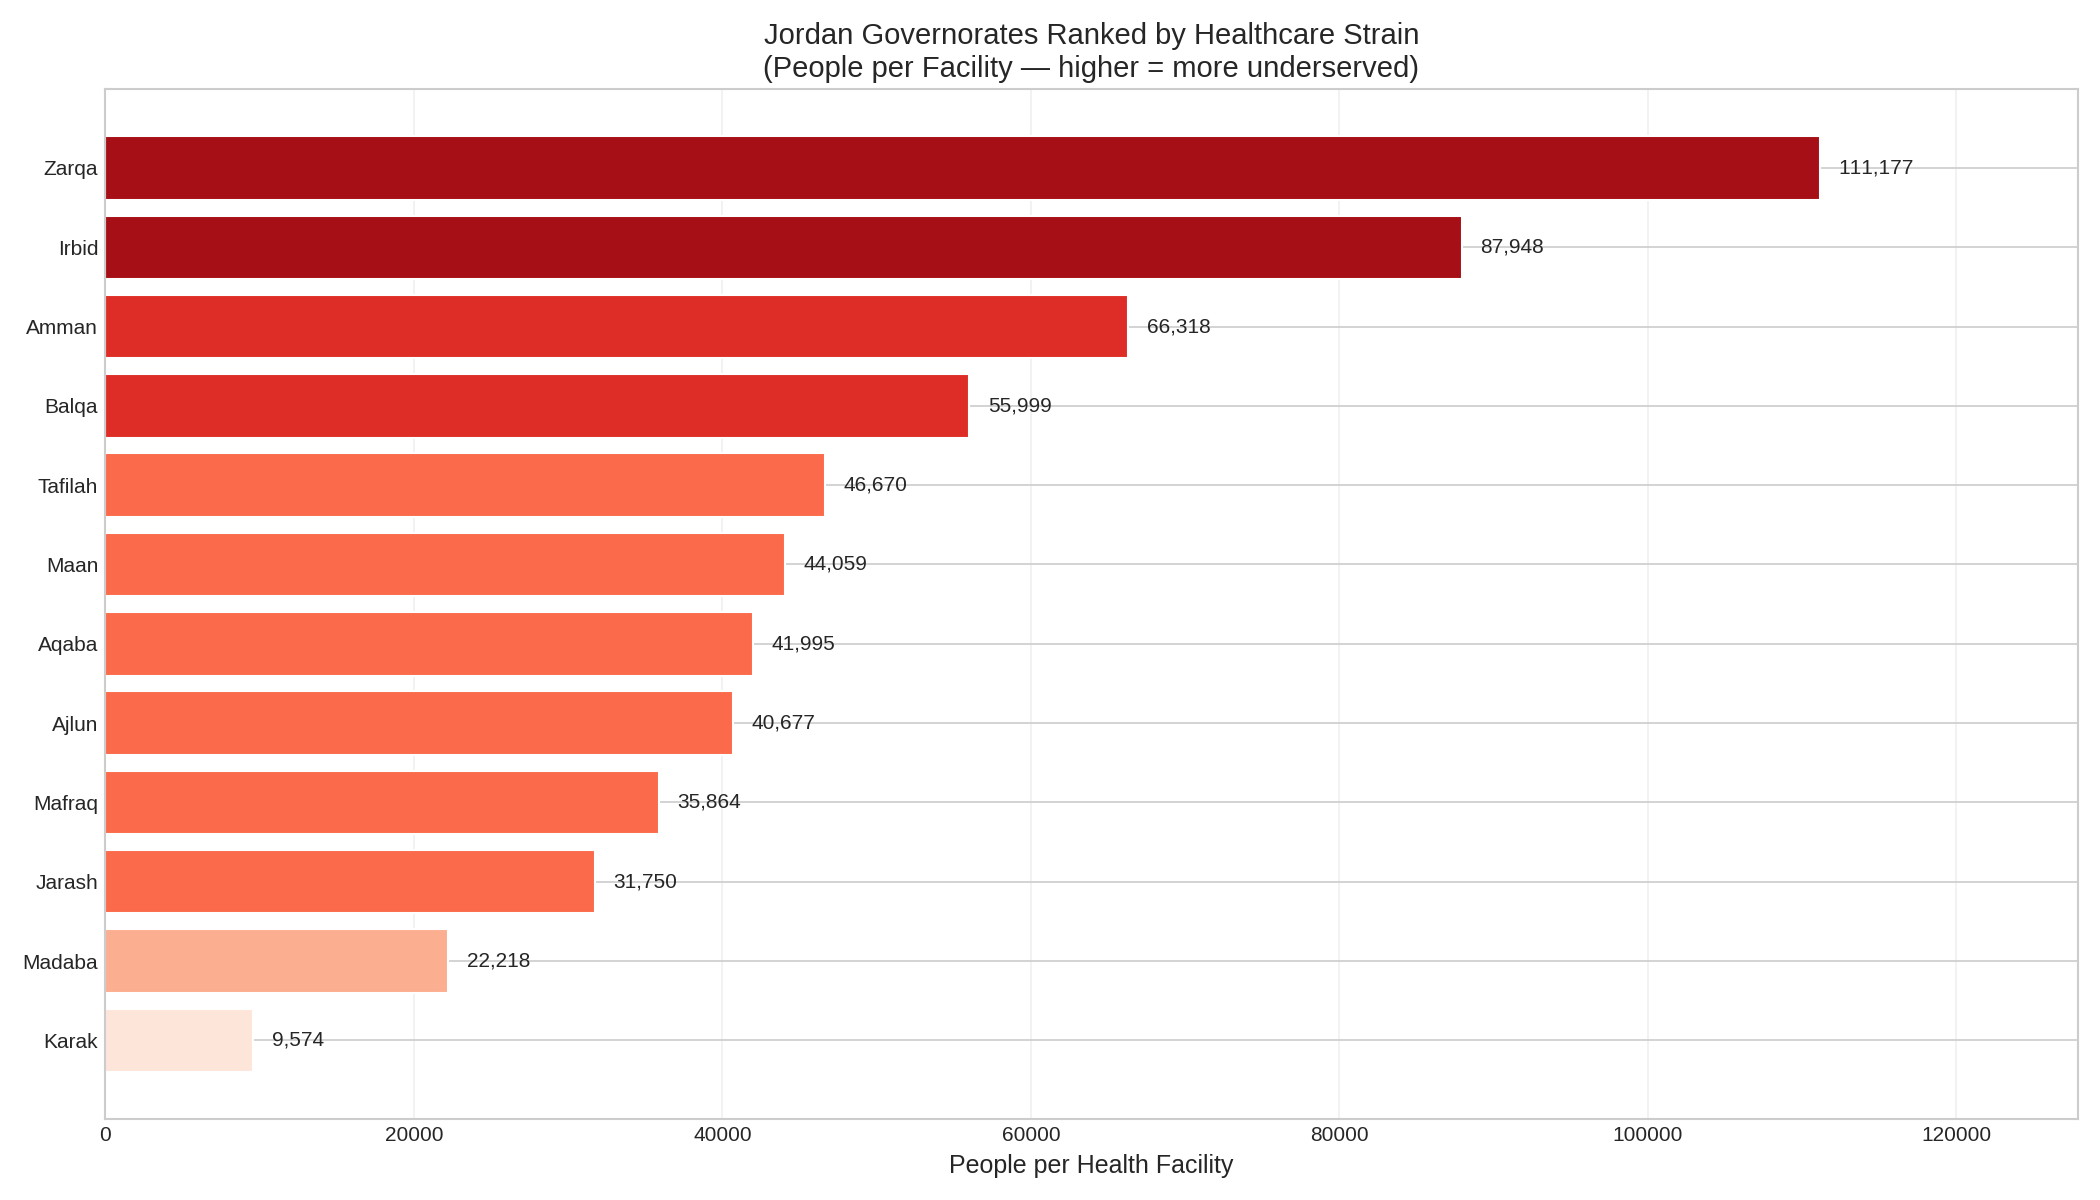

**Key findings:**

- **Zarqa is by far the most underserved governorate** — 111,177 people per facility, nearly **26% higher strain than the next-worst** (Irbid). With 1.45 million residents and only 13 facilities, each facility serves a population larger than the entire city of Ann Arbor, Michigan.
- **The top-3 big urban governorates (Zarqa, Irbid, Amman) are all severely stretched** despite having the most facilities in absolute terms — they combine high populations with moderate facility counts, pushing people-per-facility above 66K.
- **Karak is the best-served governorate by a wide margin** — 9,574 people per facility, roughly **12× less strained than Zarqa** . Despite a population of ~393K, it has 41 facilities (the second-most nationally), a legacy of its dispersed rural settlement pattern requiring closer-spaced primary care.
- **A counterintuitive finding: facility count alone misleads.** Amman has the most facilities (59) but ranks only 3rd in strain; Karak has the 2nd-most (41) yet ranks last. The big differentiator is population — Amman's 3.9M residents overwhelm its facility count, while Karak's sparse population spreads thinly across its network.
- **Balqa stands out as a mid-population governorate under unusual strain** — 672K people with just 12 facilities (56K per facility), suggesting it may benefit from facility expansion more than some larger governorates.

**Note:** Governorate name spellings vary between datasets (`Ajloun`/`Ajlun`, `Ma'an`/`Maan`, `Tafila`/`Tafilah`); I harmonized all three to the canonical geography spelling before joining. Population uses the WorldPop 2020 UN-adjusted raster (sums to ~10.2M nationally).

In [7]:
%%ask
Which governorates are most underserved — which have the most people for every health facility? Rank them from most to least stretched.

#### 4. Where's the disease burden

Reading the patient-visits skill interface to get the right loader function.

I'll compute NCD visit counts per governorate, join to population, and build the comparison. First an exploratory pass to see the rate distribution before setting map bins.

The skill helpers aren't named `skill.py`. Let me find the actual module files.

No `skill.py` — the helpers live inside the SKILL.md. Let me check the data directories and read the rest of the geography helpers.

The helper functions live inline in the SKILL.md code blocks, not separate files. I'll write a self-contained script that inlines the exact helpers from the skills. Let me first see the rate distribution to set sensible map bins.

...

The three southern governorates show **zero NCD visits** , but verification confirms they *do* have NCD visits (Ajloun: 5,528; Ma'an: 15,847; Tafila: 14,796). This is a name-spelling mismatch between the visits and geography layers. Let me diagnose the exact strings.

Found it — three spelling mismatches: `Ajloun`→`Ajlun`, `Ma'an`→`Maan`, `Tafila`→`Tafilah`. Let me apply the harmonization map and regenerate the outputs.

All 12 governorates now resolve correctly. Let me verify the output files exist, then record the name-harmonization lesson I just discovered (an edit-and-retry cycle).

The outputs are written. Since I did an edit-and-retry cycle to fix a genuine non-obvious bug, I must record the lesson before writing my final report. Let me check whether the geography skill has a Learnings.md (it's not in the pre-existing list, so it doesn't yet), and create it.

Lesson recorded. Here are the results.

---

For **non-communicable diseases (NCD)** — the NCD + MODNCD networks, **825,576 total visits** — here's how each governorate's visit volume compares to its population. I harmonized three governorate-name spelling differences between the visits and geography layers (`Ajloun`→`Ajlun`, `Ma'an`→`Maan`, `Tafila`→`Tafilah`) before joining.

| Governorate | NCD visits | Population | Visits per 1,000 | Pop share | Visit share |
|---|---:|---:|---:|---:|---:|
| Amman | 399,333 | 3,912,744 | 102.1 | 38.5% | 48.4% |
| Irbid | 132,461 | 1,846,909 | 71.7 | 18.2% | 16.0% |
| Zarqa | 69,200 | 1,445,295 | 47.9 | 14.2% | 8.4% |
| Balqa | 47,785 | 671,992 | 71.1 | 6.6% | 5.8% |
| Karak | 39,154 | 392,524 | 99.7 | 3.9% | 4.7% |
| Jarash | 38,544 | 317,499 | 121.4 | 3.1% | 4.7% |
| Mafraq | 31,631 | 573,829 | 55.1 | 5.6% | 3.8% |
| Madaba | 18,143 | 244,398 | 74.2 | 2.4% | 2.2% |
| Maan | 15,847 | 176,237 | 89.9 | 1.7% | 1.9% |
| Tafilah | 14,796 | 140,010 | 105.7 | 1.4% | 1.8% |
| Aqaba | 13,154 | 209,977 | 62.6 | 2.1% | 1.6% |
| Ajlun | 5,528 | 244,059 | 22.7 | 2.4% | 0.7% |


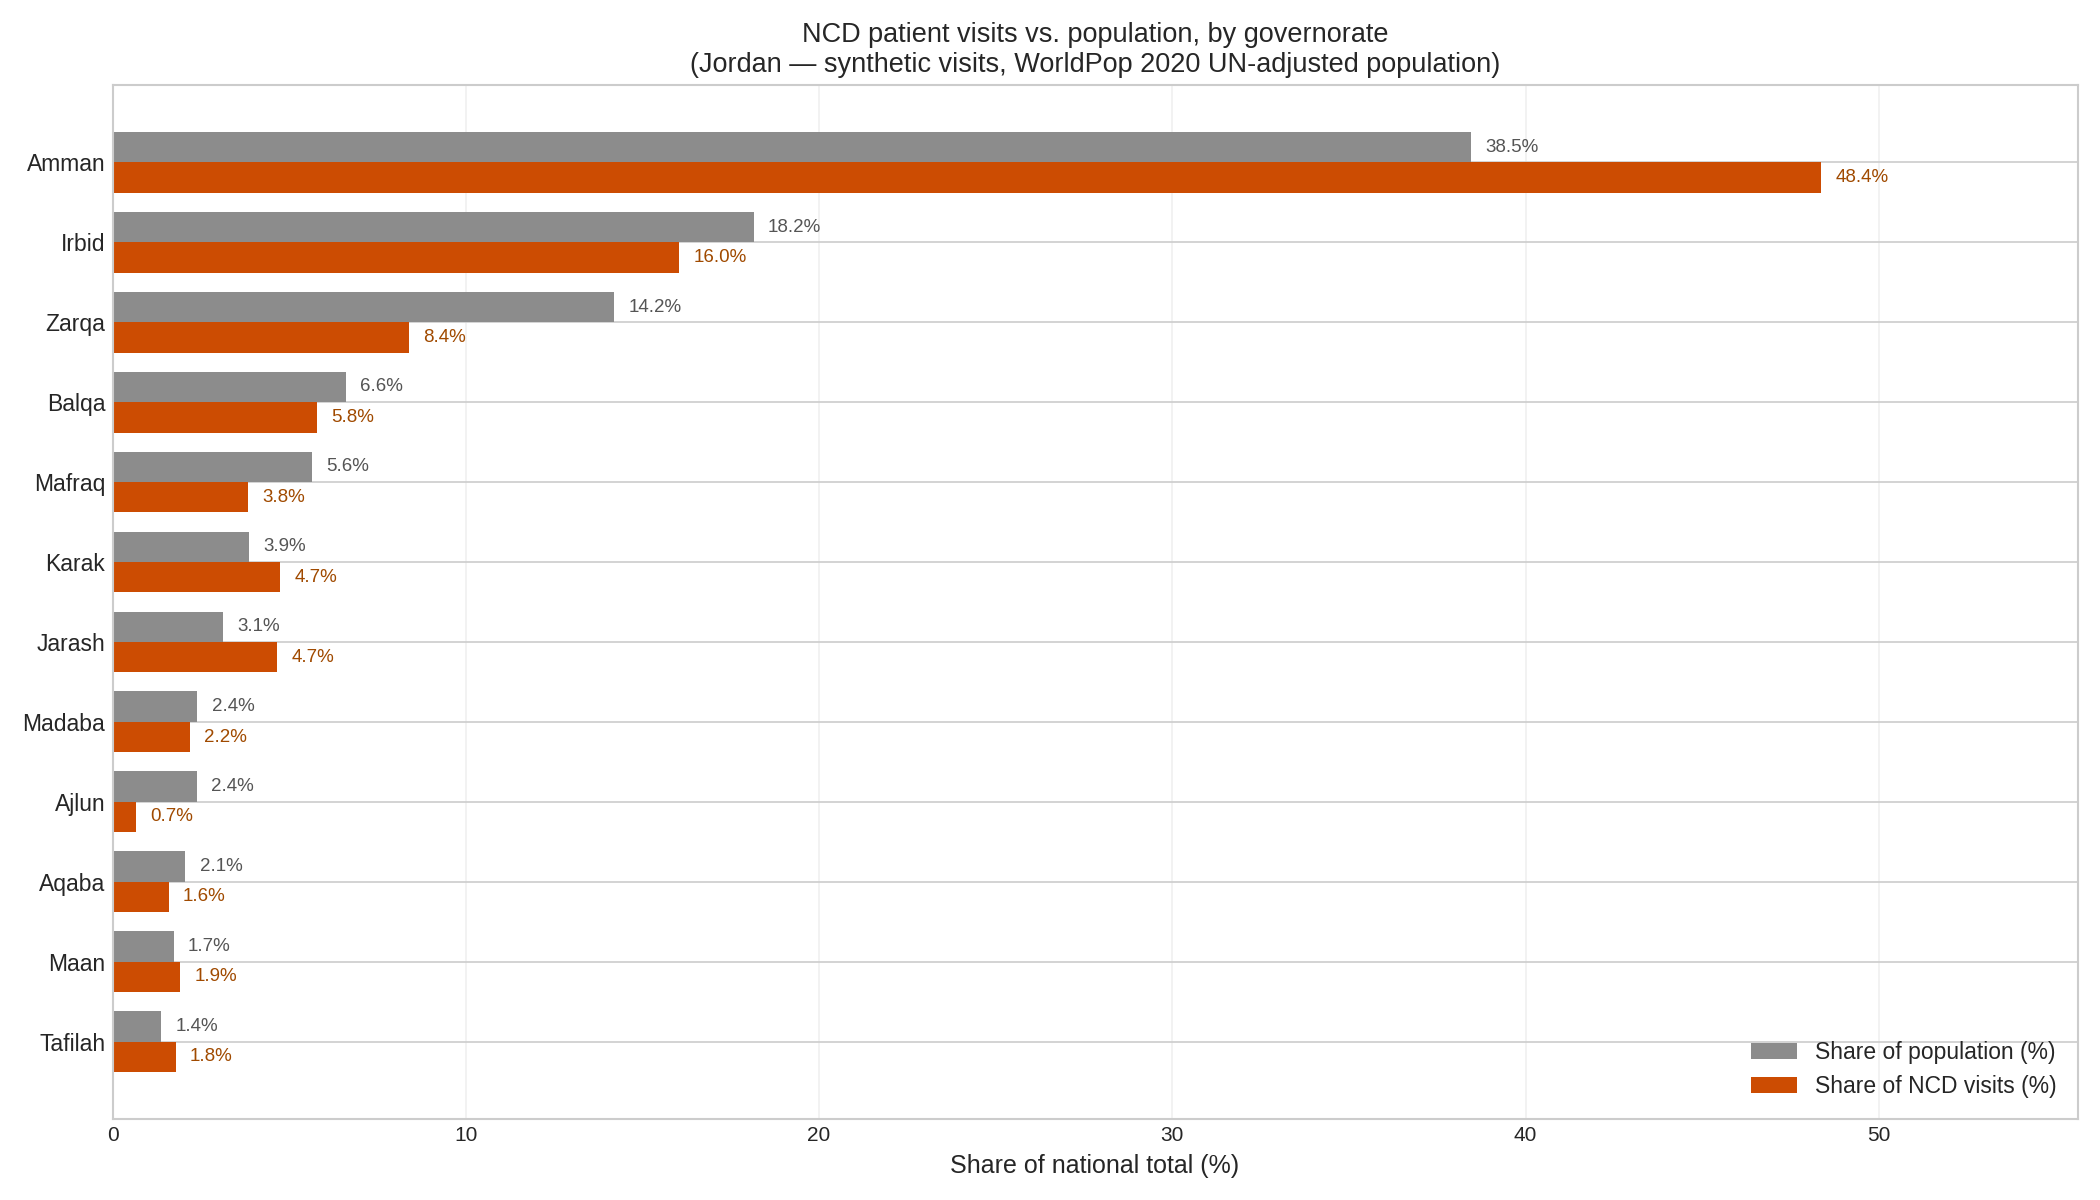

**Key findings:**

- **Amman dominates NCD care, even beyond its population share.** It holds **38.5% of the population** but generates **48.4% of NCD visits** — 399K visits, **3× the next governorate** (Irbid, 132K). Amman is a national referral hub drawing NCD patients from other governorates.
- **The most striking mismatch is Zarqa.** It's the **3rd-most-populous governorate (14.2% of population, 1.45M people)** but accounts for only **8.4% of NCD visits** with the **lowest utilization rate in the country: 47.9 visits per 1,000** . This is the same governorate identified earlier as the most facility-stretched (111K people per facility) — the combination of high population, low facility capacity, and low recorded NCD visits points to **significant unmet NCD demand** .
- **Three small southern governorates punch above their weight in utilization rate.** **Jarash (121.4/1k)** , **Tafilah (105.7/1k)** , and **Karak (99.7/1k)** all exceed Amman's rate (102.1/1k) despite having far fewer facilities and people. This may reflect older demographics, strong primary-care access (Karak had the best facilities-per-capita ratio in the earlier analysis), or different NCD recording practices.
- **Ajlun has by far the lowest NCD utilization rate: 22.7 visits per 1,000** — less than a quarter of Amman's rate, despite holding 2.4% of the population. With 244K people and 6 facilities, it is both small and relatively well-served for infectious diseases, yet records very few NCD visits — a possible gap in chronic-disease detection or recording.
- **Visit share roughly tracks population share for the mid-tier governorates** (Balqa, Mafraq, Madaba, Maan, Tafilah, Aqaba all fall within ~1 point of their population share), suggesting NCD demand is broadly proportional to population outside the extremes of Amman (over-served) and Zarqa/Ajlun (under-served).

In [8]:
%%ask
For non-communicable diseases, which governorates have the most patient visits,
and how does that compare with how many people live there?